[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juanyepesp/ISIS-4825_202610_IMAGENES_Y_VISION/blob/main/Laboratorio_07/Taller/MISIS4825_Laboratorio07_Taller.ipynb)

# Laboratorio 07 - Taller: Fundamentos de Machine Learning y Redes Neuronales

## Introducción

En este taller exploraremos el uso de TensorFlow y Keras para el diseño y entrenamiento de redes neuronales perceptrón multicapa. Utilizaremos el conjunto de datos **Pizza or not pizza?** para construir un modelo capaz de clasificar imágenes de acuerdo a su clase.

## Contenido del Taller

1. **Preprocesamiento de Datos**  
   - Implemente técnicas de preprocesamiento como normalización, estandarización y aumentación de datos utilizando TensorFlow y Keras.  
   - Adicionalmente, puede aplicar cualquier procesamiento explicado previamente en el curso.  
   - Justifique cada técnica de preprocesamiento seleccionada y analice su impacto en el desempeño del modelo.

2. **Construcción de un Modelo de Red Neuronal Perceptrón Multicapa**  
   - Desarrolle un modelo de red neuronal perceptrón multicapa utilizando Keras.  
   - Discuta la elección de la arquitectura, detallando el número de capas, la cantidad de neuronas por capa y las funciones de activación empleadas.

3. **Definición de Funciones de Callbacks para Monitorear el Entrenamiento**  
   - Implemente callbacks en TensorFlow y Keras para monitorear el proceso de entrenamiento.  
   - Explique cómo estos callbacks pueden ayudar a identificar problemas como el sobreajuste o un entrenamiento insuficiente.  
   - Justifique la selección y configuración de cada callback.

4. **Entrenamiento y Exploración de Resultados**  
   - Detalle el proceso de entrenamiento, incluyendo la elección de la tasa de aprendizaje, el optimizador y la función de pérdida.  
   - Analice los resultados obtenidos utilizando métricas de desempeño como precisión, recall y F1-score.  
   - Compare los resultados y discuta posibles mejoras en el modelo.

## Datos

[Pizza or not pizza?](https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza)

---

In [34]:
# librerías
import os
import json
import random
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import cv2
from PIL import Image

import kagglehub

import tensorflow as tf
from tensorflow import keras
from keras.models import load_model
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Input, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


### 1. **Preprocesamiento de Datos**  
   - Implemente técnicas de preprocesamiento como normalización, estandarización y aumentación de datos utilizando TensorFlow y Keras.  
   - Adicionalmente, puede aplicar cualquier procesamiento explicado previamente en el curso.  
   - Justifique cada técnica de preprocesamiento seleccionada y analice su impacto en el desempeño del modelo.

En primer lugar, cargamos el dataset y visualizamos la estructura de la carpeta.

In [35]:
# cargar el dataset
path = kagglehub.dataset_download("carlosrunner/pizza-not-pizza")
print("Path to dataset files:", path)

# path con las imagenes - están en la carpeta pizza_not_pizza
base_path = os.path.join(path, 'pizza_not_pizza')

# iterar por cada subcarpeta
for category in os.listdir(base_path):
    category_path = os.path.join(base_path, category)

    # si es una carpeta, ver cuantos archivos tiene
    if os.path.isdir(category_path):
        num_files = len(os.listdir(category_path))
        print(f"Carpeta '{category}': {num_files} archivos")

Using Colab cache for faster access to the 'pizza-not-pizza' dataset.
Path to dataset files: /kaggle/input/pizza-not-pizza
Carpeta 'not_pizza': 983 archivos
Carpeta 'pizza': 983 archivos


Se cuenta con dos carpetas correspondientes a dos categorías, pizza y not_pizza. El dataset es completamente balanceado, con 983 imagenes por cada una de las categorías.

Se determina entonces que se trabajará con un problema de **clasificación binario**, lo que ayudará posteriormente con la definición de la arquitectura de la red y la función de costo.

A continuación, se presentan algunos ejemplos de las imágenes en cada categoría.

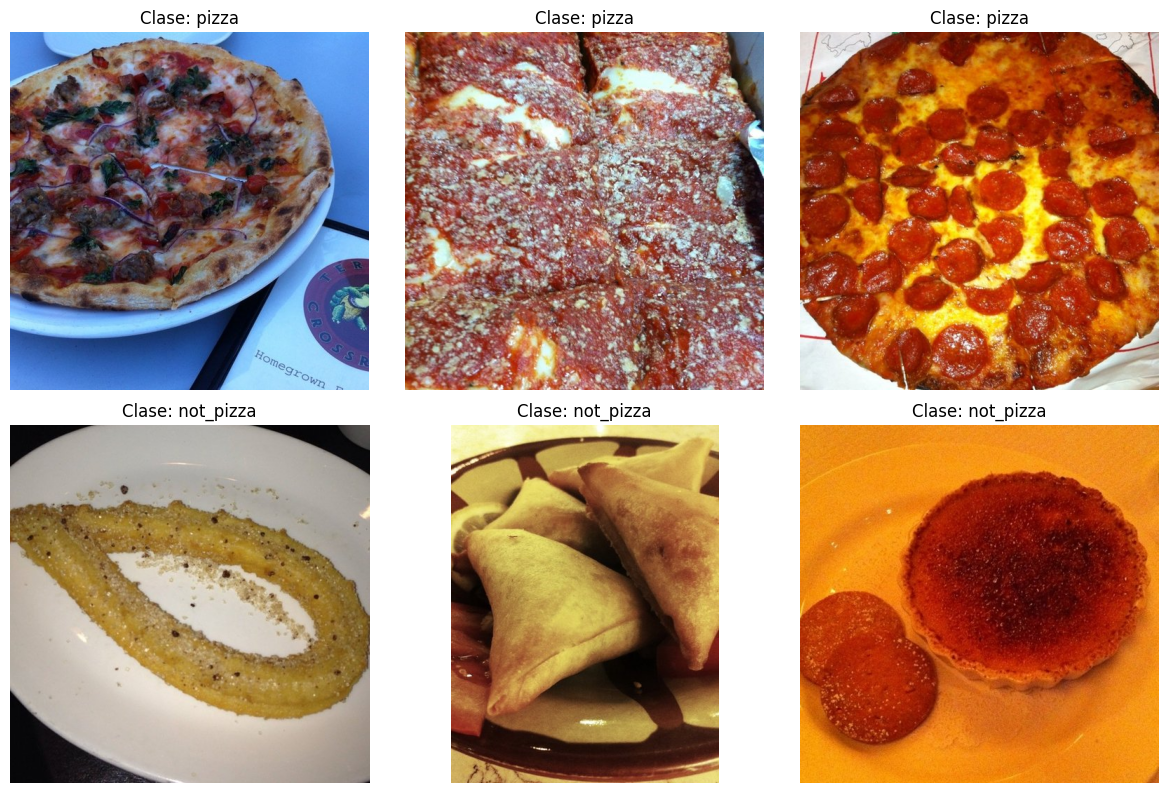

In [36]:
# configurar una semilla
random.seed(26)

base_path = os.path.join(path, 'pizza_not_pizza')
categories = ['pizza', 'not_pizza']

# configurar la figura
plt.figure(figsize=(12, 8))

for i, category in enumerate(categories):
    category_path = os.path.join(base_path, category)

    # elegir tres imagenes al azar por cada categoría
    all_images = os.listdir(category_path)
    selected_images = random.sample(all_images, 3)

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(category_path, img_name)
        img = Image.open(img_path)

        plt.subplot(2, 3, i * 3 + j + 1)
        plt.imshow(img)
        plt.title(f"Clase: {category}")
        plt.axis('off')

plt.tight_layout()
plt.show()

Para poder entrenar el modelo se crea una dataframe con los archivos de las imágenes y su etiqueta correspondiente.

In [37]:
# crear un dataframe con el path de la imagen y su categoría respectiva
data = []
for category in categories:
    category_path = os.path.join(base_path, category)
    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        data.append({'filepath': img_path, 'label': category})

df_pizza_not_pizza = pd.DataFrame(data)
df_pizza_not_pizza.head()

,filepath,label
0,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza
1,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza
2,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza
3,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza
4,/kaggle/input/pizza-not-pizza/pizza_not_pizza/...,pizza


Con el propósito de no alterar los datos de prueba y validación, antes de procesar las imágenes se separa en los conjuntos de entrenamiento, validación y prueba. Se fija una semilla para reproducibilidad.

In [38]:
# separamos los datos en train, val y test
train_df, test_val_df = train_test_split(df_pizza_not_pizza, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_val_df, test_size=2/3, random_state=42)

print("Total de imágenes:", len(df_pizza_not_pizza))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))

Total de imágenes: 1966
Entrenamiento: 1376
Validación: 394
Test: 196


Tras observar algunas imágenes de referencia y teniendo en cuenta el contexto del problema (clasificar imágenes en pizza o no pizza), se define el siguiente procesamiento de los datos.

1. **Aumento de saturación**: se evidencia que una de las características distintivas de la pizza son los colores correspondientes a la masa, queso y toppings. Con el propósito de acentuar dichos colores, se transforma la imagen al espacio de color HSV, donde la segunda dimensión corresponde precisamente a la saturación, y se aumenta por un factor constante (1.3). Este procedimiento se hace en todo el dataset. Al finalizar el proceso, se vuelve a pasar la imagen a RGB.

2. **GaussianBlur**: con el propósito de eliminar ruido no significativo a la hora de identificar una pizza, se aplica un desenfoque gaussiano con un kernel de tamaño 3x3. Nuevamente, este procedimiento se realiza en todo el dataset, incluyendo los conjuntos de validación y test.

3. **Normalización**: se escalan los píxeles de [0-255] a $[0, 1]$ con el fin de facilitar la convergencia del gradiente descendente, evitando que los pesos de la red oscilen y acelerando el aprendizaje. La normalización se realiza en los tres conjuntos.

4. **Estandarización**: se realiza una estandarización por sample, lo que significa que para cada imagen individual se resta su media y se divide por su desviación estándar. A diferencia de la estandarización global, este enfoque compensa las variaciones de iluminación y contraste específicas de cada imagen, permitiendo que la red neuronal se enfoque en patrones estructurales y cromáticos consistentes entre clases. Al aplicar la estandarización por muestra, es necesario realizar el mismo proceso en los tres conjuntos de datos.

5. **Data Augmentation**: el aumento de datos aplicado se basa en rotar aleatoriamente las imágenes hasta 25 grados, pues al rotar una pizza la imagen se verá de forma muy similar a la original. Se aplica además un zoom de hasta un 20% de la imagen y un flip horizontal para exponer al modelo a variaciones de perspectiva y escala, forzándolo a aprender patrones invariantes y reduciendo el riesgo de sobreajuste.

6. **Redimensionamiento**: se estandarizan todas las imágenes a una dimensión común (128x128) para que la arquitectura de la red pueda procesar los datos en lotes (batches) de forma computacionalmente eficiente.

In [39]:
def preprocesamiento(img):
    # asegurar que la entrada sea de 0-255
    img_uint8 = img.astype("uint8")

    # pasar a hsv y aumentar la saturación
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV).astype("float32")
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * 1.3, 0, 255)

    # devolver a rgb
    img_rgb = cv2.cvtColor(hsv.astype("uint8"), cv2.COLOR_HSV2RGB)

    # aplicar desenfoque
    img_blurred = cv2.GaussianBlur(img_rgb, (3, 3), 0)

    # asegurar que esté de 0-255 para que no falle la normalización
    return img_rgb.astype("float32")

In [40]:
# data generator para train
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocesamiento,
    rescale=1./255,
    samplewise_center=True,
    samplewise_std_normalization=True,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
)

# para train normalizar y estandarizar con la media y desviación estandar de las imagenes de train
test_val_datagen = keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocesamiento,
    rescale=1./255,
    samplewise_center=True,
    samplewise_std_normalization=True,
)

# ajustar
train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='binary'
)

val_gen = test_val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='binary', shuffle=False
)

test_gen = test_val_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(128, 128), batch_size=32, class_mode='binary', shuffle=False
)

Found 1376 validated image filenames belonging to 2 classes.
Found 394 validated image filenames belonging to 2 classes.
Found 196 validated image filenames belonging to 2 classes.


In [41]:
# verificar que se tomen correctamente las clases
train_gen.class_indices

{'not_pizza': 0, 'pizza': 1}

### 2. **Construcción de un Modelo de Red Neuronal Perceptrón Multicapa**  
   - Desarrolle un modelo de red neuronal perceptrón multicapa utilizando Keras.  
   - Discuta la elección de la arquitectura, detallando el número de capas, la cantidad de neuronas por capa y las funciones de activación empleadas.

A continuación realizamos la definición del modelo perceptrón multicapa utilizando Keras. El modelo cuenta con la sigueinte arquitectura:
- Flatten: inicialmente, se aplana la imagen de entrada. Esta imagen está representada como tres matrices (tres canales) de tamaño 128x128. Tras aplanarlo, se obtendrá un vector de dimensión 128x128x3=49152.
- BatchNormalization: se utiliza para estabilizar el entrenamiento al normalizar las salidas de las capas densas. Al asegurar que los datos que pasan de una capa a otra mantengan una escala constante (media cercana a cero), se evita que los gradientes se vuelvan inestables. Esto permite que el modelo converja en menos tiempo y sea menos sensible a la inicialización de los pesos.
- Capas densas: consiste en una secuencia de tres capas (256, 128, 64 neuronas) con funciones de activación ReLU. Esta configuración ayuda al modelo a capturar patrones no lineales mediante representaciones de alta dimensionalidad antes de la capa de salida.
- Dropout: entre cada capa densa y la siguiente se aplica un dropout de forma que el modelo generalice.
- Capa de salida: la capa de salida contará con una neurona con función de activación sigmoide, pues se está tratando con un problema de clasificación binaria.

In [42]:
# definicion del modelo
model = Sequential([
    Input(shape=(128, 128, 3)),
    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
# resumen del modelo
model.summary()

# compilar el modelo
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,625,921 (48.16 MB)

 Trainable params: 12,625,153 (48.16 MB)

 Non-trainable params: 768 (3.00 KB)

Como se puede observar con el resumen del modelo, hay un total de 12,625,153 parametros entrenables y 768 parámetros no entrenables correspondientes a la normalización por batches.

### 3. **Definición de Funciones de Callbacks para Monitorear el Entrenamiento**  
   - Implemente callbacks en TensorFlow y Keras para monitorear el proceso de entrenamiento.  
   - Explique cómo estos callbacks pueden ayudar a identificar problemas como el sobreajuste o un entrenamiento insuficiente.  
   - Justifique la selección y configuración de cada callback.

Para entrenar el modelo se implementan los siguientes callbacks.

- ModelCheckpoint: se utiliza para guardar automáticamente el estado del modelo cada vez que se registra una mejora en la pérdida de validación (val_loss). Esto garantiza que, ante una interrupción o una degradación posterior del rendimiento, siempre se conserve el archivo con los pesos óptimos.

- EarlyStopping: el early stopping se usa principalmente para mitigar el sobreajuste. Si la métrica de validación deja de mejorar durante un intervalo de 10 épocas (patience=10), el entrenamiento se detiene. Al activar restore_best_weights=True, aseguramos que el modelo final no sea la versión sobreentrenada de la última época, sino la que mejor capacidad de generalización demostró. Al hacer esto, se evita que el entrenamiento continúe ajustandose al conjunto de entrenamiento pero sin presentar una verdadera mejora en el conjunto de validación.

- ReduceLROnPlateau: ayuda a prevenir un entrenamiento insuficiente cuando el optimizador se estanca en una "meseta" de la función de pérdida. Si tras 5 épocas no hay mejora, se reduce la tasa de aprendizaje por un factor de 0.1. Esto permite realizar ajustes más finos en los pesos, facilitando que el modelo escape de mínimos locales o supere áreas de gradiente plano para alcanzar un mejor mínimo global.

In [43]:
# checkpoint del modelo
model_checkpoint = ModelCheckpoint('best_model.h5',
                                   save_best_only=True,
                                   monitor='val_loss',
                                   mode='min')

# early stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=15,
                               verbose=1,
                               restore_best_weights=True,
                               mode='min')

# reducción del lr
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.1,
                              patience=5,
                              verbose=1,
                              min_lr=1e-6,
                              mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

with tf.device('/device:GPU:0'):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks
    )

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.6065 - loss: 0.7802

43/43 ━━━━━━━━━━━━━━━━━━━━ 24s 506ms/step - accuracy: 0.6243 - loss: 0.7206 - val_accuracy: 0.6675 - val_loss: 0.7551 - learning_rate: 0.0010
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.6300 - loss: 0.6635

43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 478ms/step - accuracy: 0.6446 - loss: 0.6442 - val_accuracy: 0.7056 - val_loss: 0.6486 - learning_rate: 0.0010
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.6569 - loss: 0.6222

43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 440ms/step - accuracy: 0.6555 - loss: 0.6302 - val_accuracy: 0.6904 - val_loss: 0.6044 - learning_rate: 0.0010
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 427ms/step - accuracy: 0.6730 - loss: 0.6143 - val_accuracy: 0.7157 - val_loss: 0.6082 - learning_rate: 0.0010
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.7112 - loss: 0.5851

43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 432ms/step - accuracy: 0.6962 - loss: 0.5905 - val_accuracy: 0.6777 - val_loss: 0.5805 - learning_rate: 0.0010
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 439ms/step - accuracy: 0.6991 - loss: 0.5795 - val_accuracy: 0.6980 - val_loss: 0.6120 - learning_rate: 0.0010
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7164 - loss: 0.5790

43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 495ms/step - accuracy: 0.7049 - loss: 0.5846 - val_accuracy: 0.7157 - val_loss: 0.5735 - learning_rate: 0.0010
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6889 - loss: 0.5861

43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 422ms/step - accuracy: 0.6831 - loss: 0.5849 - val_accuracy: 0.7183 - val_loss: 0.5668 - learning_rate: 0.0010
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 417ms/step - accuracy: 0.7078 - loss: 0.5778 - val_accuracy: 0.6878 - val_loss: 0.5740 - learning_rate: 0.0010
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 417ms/step - accuracy: 0.7108 - loss: 0.5618 - val_accuracy: 0.7107 - val_loss: 0.5788 - learning_rate: 0.0010
Epoch 11/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 422ms/step - accuracy: 0.7071 - loss: 0.5703 - val_accuracy: 0.7030 - val_loss: 0.5811 - learning_rate: 0.0010
Epoch 12/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 19s 447ms/step - accuracy: 0.7049 - loss: 0.5616 - val_accuracy: 0.7081 - val_loss: 0.5818 - learning_rate: 0.0010
Epoch 13/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.7122 - loss: 0.5582
Epoch 13: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 415ms/step - accuracy: 0.7224 - loss: 0.5487 - 

43/43 ━━━━━━━━━━━━━━━━━━━━ 17s 405ms/step - accuracy: 0.7202 - loss: 0.5547 - val_accuracy: 0.7157 - val_loss: 0.5616 - learning_rate: 1.0000e-04
Epoch 16/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7329 - loss: 0.5398

43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 415ms/step - accuracy: 0.7391 - loss: 0.5365 - val_accuracy: 0.7234 - val_loss: 0.5557 - learning_rate: 1.0000e-04
Epoch 17/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.7299 - loss: 0.5433

43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 456ms/step - accuracy: 0.7384 - loss: 0.5280 - val_accuracy: 0.7208 - val_loss: 0.5545 - learning_rate: 1.0000e-04
Epoch 18/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 421ms/step - accuracy: 0.7515 - loss: 0.5224 - val_accuracy: 0.7132 - val_loss: 0.5585 - learning_rate: 1.0000e-04
Epoch 19/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 406ms/step - accuracy: 0.7435 - loss: 0.5299 - val_accuracy: 0.7081 - val_loss: 0.5598 - learning_rate: 1.0000e-04
Epoch 20/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 423ms/step - accuracy: 0.7493 - loss: 0.5060 - val_accuracy: 0.7183 - val_loss: 0.5615 - learning_rate: 1.0000e-04
Epoch 21/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 424ms/step - accuracy: 0.7413 - loss: 0.5278 - val_accuracy: 0.7157 - val_loss: 0.5591 - learning_rate: 1.0000e-04
Epoch 22/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.7279 - loss: 0.5440
Epoch 22: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
43/43 ━━━━━━━━━━━━━━━━━━━━ 22s 502ms/step - accuracy: 0.7

### 4. **Entrenamiento y Exploración de Resultados**  
   - Detalle el proceso de entrenamiento, incluyendo la elección de la tasa de aprendizaje, el optimizador y la función de pérdida.  
   - Analice los resultados obtenidos utilizando métricas de desempeño como precisión, recall y F1-score.  
   - Compare los resultados y discuta posibles mejoras en el modelo.

Para la compilación se utiliza el optimizador Adam, seleccionado por su capacidad de adaptar la tasa de aprendizaje automáticamente para acelerar la convergencia. Como función de pérdida se emplea Binary Crossentropy, ya que es la métrica ideal para cuantificar el error en problemas de clasificación binaria (pizza o no pizza). Finalmente, se utiliza el Accuracy como métrica de monitoreo para evaluar el porcentaje de aciertos del modelo durante el entrenamiento. Esta métrica es adecuada para el problema teniendo en cuenta que el dataset es balanceado y no hay un error más problemático que otro.

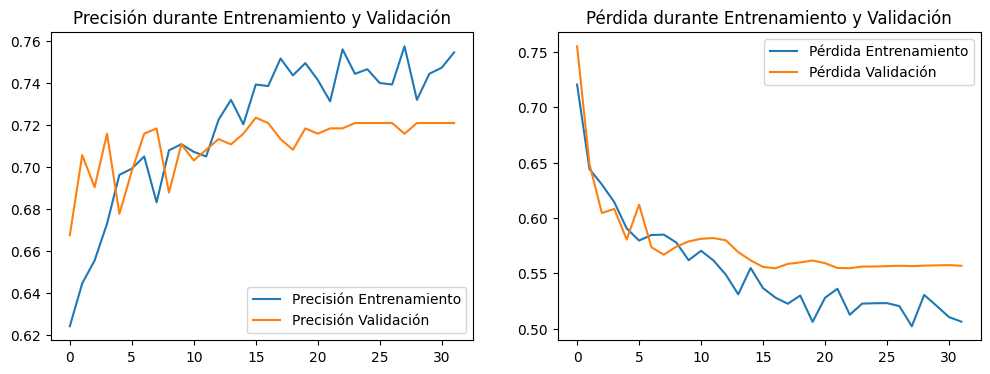

In [44]:
# Visualización de la evolución del entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión Validación')
plt.legend(loc='lower right')
plt.title('Precisión durante Entrenamiento y Validación')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida Validación')
plt.legend(loc='upper right')
plt.title('Pérdida durante Entrenamiento y Validación')
plt.show()

A partir de las gráficas de precisión y pérdida, se identifica un punto de inflexión alrededor de la época 20. Hasta este momento, ambas curvas de pérdida descienden de forma sincronizada; sin embargo, posteriormente comienzan a divergir: mientras la pérdida de entrenamiento continúa bajando, la de validación se estanca y muestra oscilaciones. Este comportamiento, sumado a que el accuracy de validación se estabiliza cerca de la época 19 frente a oscilaciones en el entrenamiento, confirma el inicio de un proceso de sobreajuste (overfitting).

Pese a esta tendencia, el uso de callbacks permitió mitigar la degradación del modelo al detener el entrenamiento antes de que la brecha de generalización fuera crítica, asegurando la recuperación de los pesos que maximizaron el desempeño en el conjunto de validación.

A continuación se obtienen las métricas y matriz de confusión del modelo aplicado en el conjunto de test.

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step


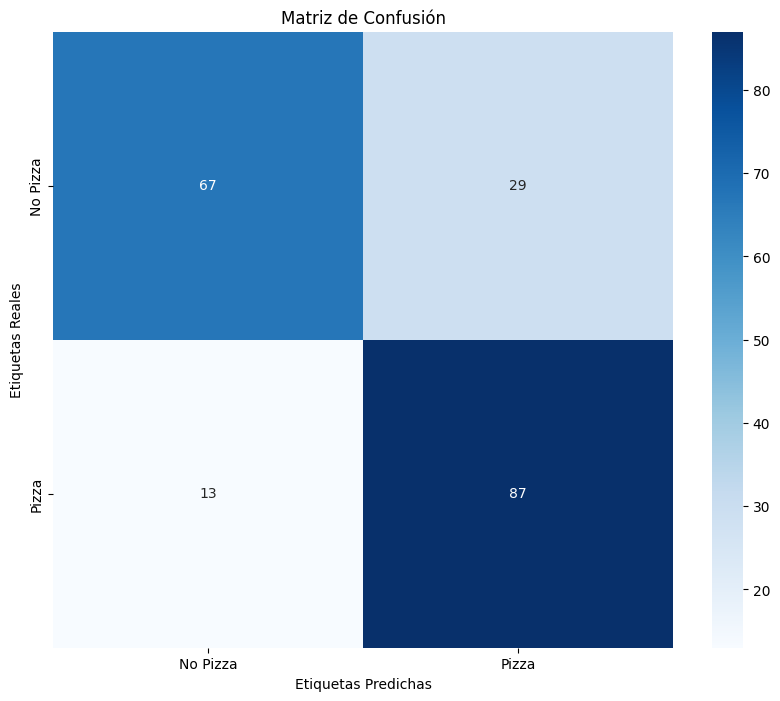

              precision    recall  f1-score   support

    No Pizza       0.84      0.70      0.76        96
       Pizza       0.75      0.87      0.81       100

    accuracy                           0.79       196
   macro avg       0.79      0.78      0.78       196
weighted avg       0.79      0.79      0.78       196



In [45]:
# cargar el mejor modelo
best_model = load_model('best_model.h5')
labels = ['No Pizza', 'Pizza']

# evaluación en conjunto de test
test_gen.reset()
predictions = best_model.predict(test_gen, verbose=1)
y_pred = (predictions > 0.5).astype("int32").flatten()
y_test = test_gen.classes

# matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues, xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión')
plt.ylabel('Etiquetas Reales')
plt.xlabel('Etiquetas Predichas')
plt.show()

# reporte de clasificación
print(classification_report(y_test, y_pred, target_names=labels))

El modelo registra un accuracy global del 79%. A continuación se detalla el comportamiento de las métricas obtenidas:

- Recall: esta métrica mide la capacidad del modelo para identificar todos los casos pertenecientes a una clase. Para la clase Pizza, el recall es de 0.87, lo que significa que el modelo detecta el 87% de las pizzas reales. Para la clase No Pizza, el recall baja a 0.70, indicando que el 30% de las imágenes que no son pizza se clasifican erróneamente como tales, es decir, son falsos negativos para esa clase.

- Precisión: mide la fiabilidad de las predicciones positivas. La clase No Pizza tiene una precisión de 0.84, mientras que la clase Pizza tiene un 0.75. Esto indica que cuando el modelo predice que una imagen es pizza, el 25% de las veces se trata de un falso positivo. Este comportamiento se puede también evidenciar en la matriz de confusión.

- F1-Score: esta métrica es una medida de equilibrio entre recall y precisión. En la clase Pizza el F1-score es de 0.81, mientras que en No Pizza es de 0.76. La diferencia refleja que el modelo tiene un desempeño más balanceado al identificar pizzas que al descartar otros objetos.

Antes de proponer mejoras al modelo, se observan algunas predicciones de imágenes en test.

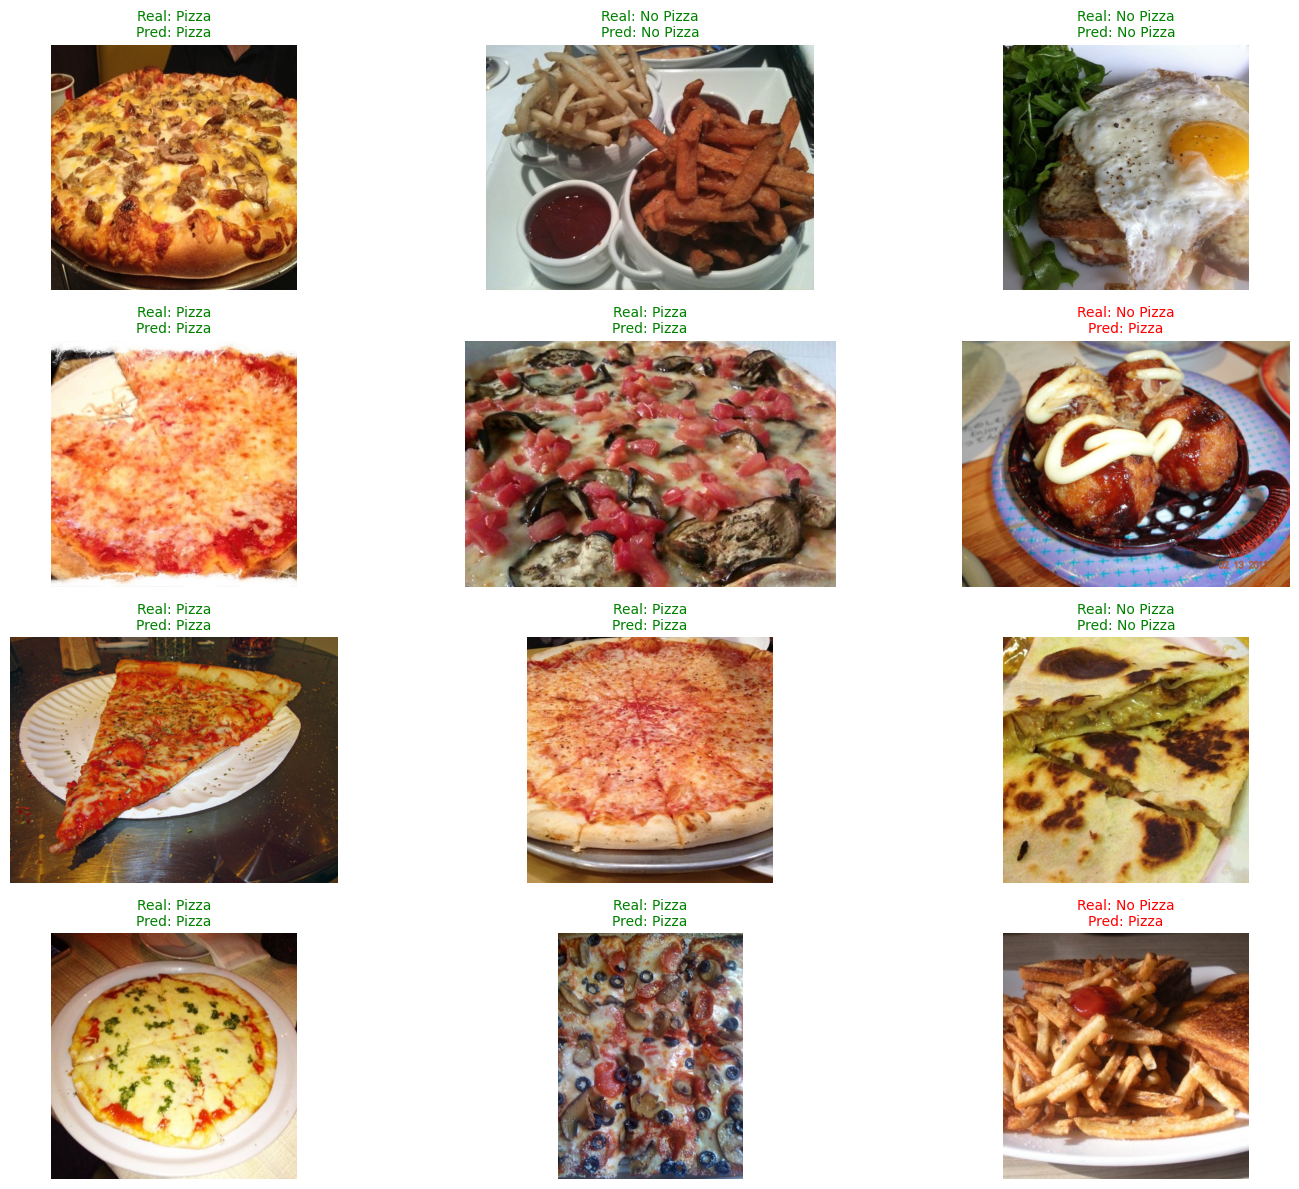

In [52]:
# número de imagenes a graficar
num_to_show = 12
num_total_test = len(y_test)

# generar 12 índices para tomar imagenes aleatorias
random_indices = np.random.choice(range(num_total_test), size=num_to_show, replace=False)

plt.figure(figsize=(15, 12))

for i, idx in enumerate(random_indices):
    plt.subplot(4, 3, i + 1)

    # carga la imagen en RGB
    img_path = os.path.join(test_gen.directory, test_gen.filenames[idx])
    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

    # obtener la etiqueta predicha y real
    actual_label = labels[y_test[idx]]
    pred_label = labels[y_pred[idx]]

    # color verde si coinciden, rojo dlc
    color = 'green' if actual_label == pred_label else 'red'

    plt.imshow(img_original)
    plt.title(f"Real: {actual_label}\nPred: {pred_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

A partir del análisis de las métricas de desempeño y la inspección de las imágenes, se identifica una mayor incidencia de error en la detección de objetos pertenecientes a la clase "No Pizza", como se había mencionado anteriormente. Esta tendencia y la observación de las imágenes anterior sugiere que el modelo presenta dificultades para distinguir entre categorías que comparten una paleta cromática similar (tonos rojos, amarillos y ocres), pero que difieren en su estructura geométrica.

La principal limitación se encuentra en el uso de la operación Flatten seguida de capas densas. Al aplanar las matrices de la imagen en un vector unidimensional, se destruye la relación espacial entre los píxeles, lo que impide que el modelo reconozca patrones morfológicos característicos. En el caso de la pizza, factores como forma circular o trinagular son descriptores fundamentales que se pierden bajo esta arquitectura. Como resultado, el clasificador prioriza la intensidad del color sobre la geometría del objeto, confundiendo alimentos de colores similares con la clase positiva.

Para mitigar estas deficiencias, se proponen las siguientes mejoras:

- Implementación de Redes Neuronales Convolucionales (CNN): El uso de filtros convolucionales facilita la detección de bordes, texturas y formas complejas que definen a la clase Pizza.

- Inclusión de mapas de bordes: Integrar un pre-procesamiento mediante detectores de bordes (como el operador Canny) o añadir una rama que procese el gradiente de la imagen podría reforzar la capacidad del modelo para diferenciar la estructura circular de la pizza frente a objetos con colores similares.